# Alpha Signal Construction & Backtesting

## Overview

We combine two models:

1. **Move Model**
   - Predicts probability that mid-price moves

2. **Sign Model**
   - Predicts direction conditional on a move

These are combined into a **trading signal**, which is then evaluated through a backtest.

---

## Objective

- Convert probabilistic predictions into a **tradable signal**
- Evaluate profitability via:
  - PnL
  - Sharpe ratio
  - Drawdown

---

## Key Idea

We model:

P(up move) = P(move) × P(up | move)

and trade based on model confidence.

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [2]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet"
)

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [3]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

does_move_mask = final_dataset["mid_price_moves"] == 1
final_dataset["mid_price_change_1_sign"] = final_dataset[
    "mid_price_change_1_sign"
].replace(-1.0, 0.0)

final_dataset[does_move_mask]["mid_price_change_1_sign"].value_counts()

mid_price_change_1_sign
1.0    9572
0.0    9214
Name: count, dtype: int64

# Features

In [4]:
features_sign = [
    "imbalance_5",
    "imbalance_1",
    "trade_volume_imbalance",
    "mid_minus_micro_log1p",
    "max_bid_ask_vol_ratio_log1p",
    "sell_volume_log1p",
    "lob_depth_ratio_3",
    "realized_vol_20_log1p",
    "log_return_2",
    "total_ask_volume_10_log1p",
    "total_bid_volume_10_log1p",
]


features_move = [
    # Vol
    "realized_vol_20_log1p",
    "realized_vol_5_log1p",
    # trade intensity
    "trade_count_log1p",
    "trade_count_change",
    # trade size
    "std_trade_size_log1p",
    "max_trade_size_log1p",
    "avg_trade_size_log1p",
    # liquidity
    "total_bid_volume_10_log1p",
    "total_book_volume_log1p",
    # volume_pressure
    "max_bid_ask_vol_ratio_log1p",
    # spread
    "rel_spread_log1p",
    # imbalance
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_3",
    # depth shape
    "lob_depth_ratio_4",
    "lob_depth_ratio_2",
    # trade_flow
    "sell_volume_log1p",
]

# models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [6]:
MODELS_MOVE = {
    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=50,
        n_jobs=4,
        random_state=42,
        max_features=0.2,
    ),
    "xgb": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    ),
}


MODELS_SIGN = {
    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=50,
        n_jobs=4,
        random_state=42,
        max_features=0.2,
    ),
    "xgb": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_lambda=1.0,
        n_jobs=1,
        random_state=42,
        eval_metric="logloss",
    ),
}

In [7]:
splits = 10
size_data = len(final_dataset)
tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data / splits))

In [8]:
move_model_target = "mid_price_moves"
sign_model_target = "mid_price_change_1_sign"

In [9]:
X = final_dataset
X_move = X[features_move]
y_move = final_dataset[move_model_target]


X_sign = X[features_sign]
y_sign = final_dataset[sign_model_target]

# Tree based

In [10]:
def train_move_model(X, y, model, tscv, name, scale=False, clip_quantiles=(0.01, 0.99)):
    n = len(X)
    fold_oof = []
    fold_aucs = []
    coefs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        oof_preds = np.full(n, np.nan)

        model_fold = model
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        lower = X_train.quantile(clip_quantiles[0])
        upper = X_train.quantile(clip_quantiles[1])

        X_train = X_train.clip(lower, upper, axis=1)
        X_test = X_test.clip(lower, upper, axis=1)
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        model_fold.fit(X_train, y_train)
        preds = model_fold.predict_proba(X_test)[:, 1]

        oof_preds[test_idx] = preds

        auc = roc_auc_score(y_test, preds)
        fold_aucs.append(auc)
        fold_oof.append(oof_preds)

        if name == "xgb":
            booster = model_fold.get_booster()
            score = booster.get_score(importance_type="gain")

            imp = pd.Series(score)
            imp = imp.reindex(X.columns, fill_value=0.0)

        else:
            imp = pd.Series(model_fold.feature_importances_, index=X.columns)

        coefs.append(imp)

    results = {
        "fold_oof": fold_oof,
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "min_auc": np.min(fold_aucs),
        "coefs": coefs,
    }
    return results

In [11]:
move_results = {}

for name, model in MODELS_MOVE.items():
    res = train_move_model(
        X_move,
        y_move,
        model,
        tscv,
        name,
    )
    move_results[name] = res

In [12]:
df_linear = pd.DataFrame(
    {
        k: {
            "mean_auc": v["mean_auc"],
            "std_auc": v["std_auc"],
            "min_auc": v["min_auc"],
            "ir": v["mean_auc"] / (v["std_auc"] + 1e-8),
        }
        for k, v in move_results.items()
    }
).T

df_linear.sort_values("ir", ascending=False)

,mean_auc,std_auc,min_auc,ir
rf,0.727489,0.056251,0.664314,12.932853
xgb,0.707073,0.057640,0.638373,12.267097


In [13]:
def train_sign_model(X, y, model, tscv, name, scale=False, clip_quantiles=(0.01, 0.99)):
    n = len(X)
    fold_oof = []
    fold_full_oof = []
    fold_aucs = []
    coefs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        oof_preds = np.full(n, np.nan)
        oof_full_preds = np.full(n, np.nan)

        model_fold = model

        X_train_full = X.iloc[train_idx].copy()
        X_test_full = X.iloc[test_idx].copy()

        y_train_full = y.iloc[train_idx]
        y_test_full = y.iloc[test_idx]

        lower = X_train_full.quantile(clip_quantiles[0])
        upper = X_train_full.quantile(clip_quantiles[1])

        X_train_full = X_train_full.clip(lower, upper, axis=1)
        X_test_full = X_test_full.clip(lower, upper, axis=1)
        if scale:
            scaler = StandardScaler()
            X_train_full = scaler.fit_transform(X_train_full)
            X_test_full = scaler.transform(X_test_full)

        train_mask = (final_dataset.iloc[train_idx]["mid_price_moves"] == 1).values
        test_mask = (final_dataset.iloc[test_idx]["mid_price_moves"] == 1).values

        X_train_sign = X_train_full.loc[train_mask]
        y_train_sign = y_train_full.loc[train_mask]

        model_fold.fit(X_train_sign, y_train_sign)

        preds_full = model_fold.predict_proba(X_test_full)[:, 1]
        oof_full_preds[test_idx] = preds_full

        test_index = X_test_full.index
        test_move_index = test_index[test_mask]

        X_test_sign = X_test_full.loc[test_move_index]
        y_test_sign = y_test_full.loc[test_move_index]

        preds = model_fold.predict_proba(X_test_sign.loc[test_move_index])[:, 1]
        oof_preds[test_move_index] = preds

        auc = roc_auc_score(y_test_sign, preds)

        fold_aucs.append(auc)
        fold_oof.append(oof_preds)
        fold_full_oof.append(oof_full_preds)
        if name == "xgb":
            booster = model_fold.get_booster()
            score = booster.get_score(importance_type="gain")

            imp = pd.Series(score)
            imp = imp.reindex(X.columns, fill_value=0.0)

        else:
            imp = pd.Series(model_fold.feature_importances_, index=X.columns)

        coefs.append(imp)

    results = {
        "fold_oof": fold_oof,
        "fold_full_oof": fold_full_oof,
        "fold_aucs": fold_aucs,
        "mean_auc": np.mean(fold_aucs),
        "std_auc": np.std(fold_aucs),
        "min_auc": np.min(fold_aucs),
        "coefs": coefs,
    }
    return results

In [14]:
sign_results = {}

for name, model in MODELS_SIGN.items():
    res = train_sign_model(
        X_sign,
        y_sign,
        model,
        tscv,
        name,
    )
    sign_results[name] = res

In [15]:
df_linear = pd.DataFrame(
    {
        k: {
            "mean_auc": v["mean_auc"],
            "std_auc": v["std_auc"],
            "min_auc": v["min_auc"],
            "ir": v["mean_auc"] / (v["std_auc"] + 1e-8),
        }
        for k, v in sign_results.items()
    }
).T

df_linear.sort_values("ir", ascending=False)

,mean_auc,std_auc,min_auc,ir
rf,0.846889,0.059374,0.765317,14.263653
xgb,0.846015,0.059415,0.768182,14.238981


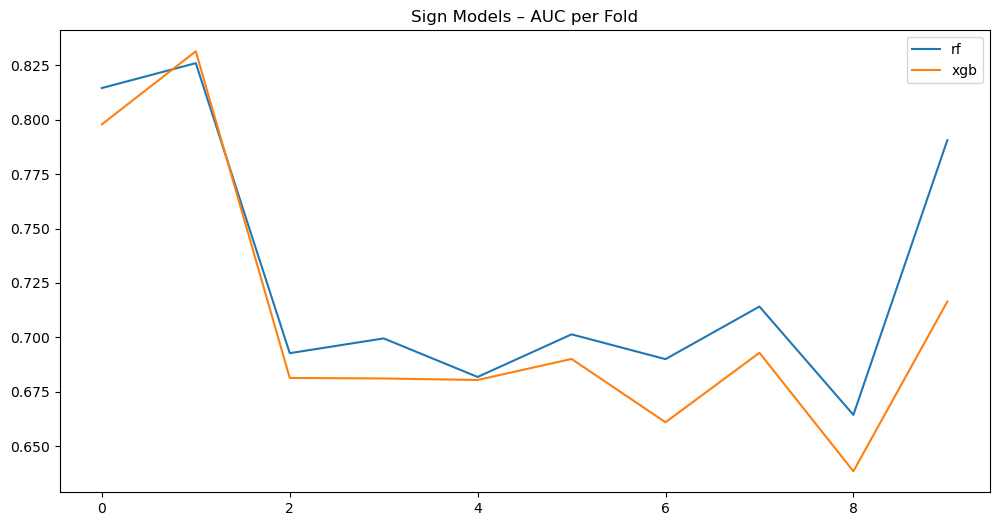

In [16]:
plt.figure(figsize=(12, 6))

for k, v in move_results.items():
    plt.plot(v["fold_aucs"], label=k)

plt.legend()
plt.title("Sign Models – AUC per Fold")
plt.show()

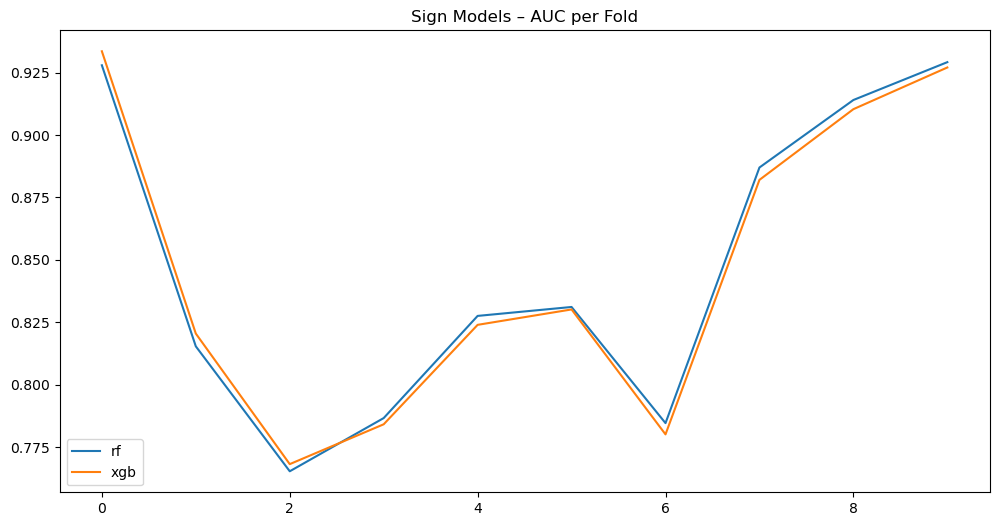

In [17]:
plt.figure(figsize=(12, 6))

for k, v in sign_results.items():
    plt.plot(v["fold_aucs"], label=k)

plt.legend()
plt.title("Sign Models – AUC per Fold")
plt.show()

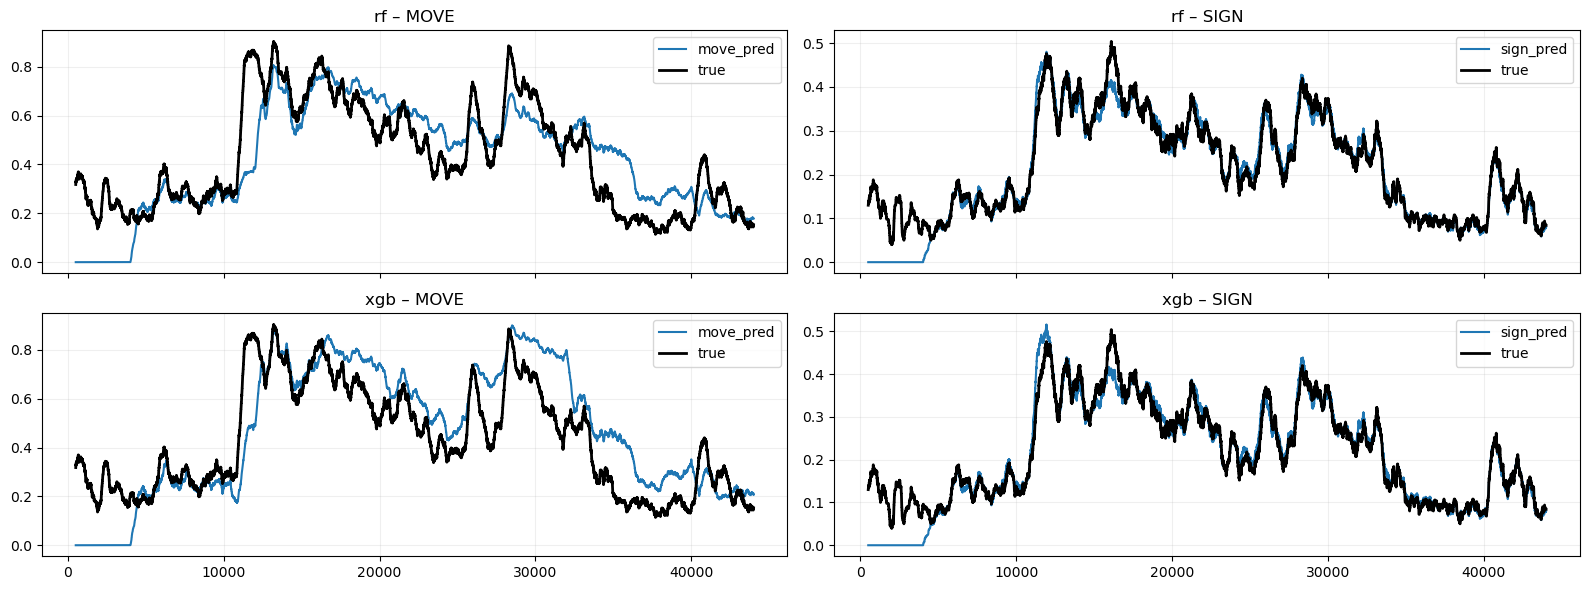

In [18]:
window = 500

y_move_true = y_move.values
y_sign_true = y_sign.values

move_smooth = pd.Series(y_move_true).rolling(window).mean()
sign_smooth = pd.Series(y_sign_true).rolling(window).mean()

model_names = list(move_results.keys())
n_models = len(model_names)

fig, axes = plt.subplots(n_models, 2, figsize=(16, 3 * n_models), sharex=True)

if n_models == 1:
    axes = [axes]

for i, name in enumerate(model_names):

    move_v = move_results[name]
    sign_v = sign_results[name]

    move_preds = np.nansum(move_v["fold_oof"], axis=0)
    move_pred_smooth = pd.Series(move_preds).rolling(window).mean()

    axes[i][0].plot(move_pred_smooth, label="move_pred")
    axes[i][0].plot(move_smooth, color="black", linewidth=2, label="true")
    axes[i][0].set_title(f"{name} – MOVE")
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.2)

    # --- SIGN ---
    sign_preds = np.nansum(sign_v["fold_oof"], axis=0)
    sign_pred_smooth = pd.Series(sign_preds).rolling(window).mean()

    axes[i][1].plot(sign_pred_smooth, label="sign_pred")
    axes[i][1].plot(sign_smooth, color="black", linewidth=2, label="true")
    axes[i][1].set_title(f"{name} – SIGN")
    axes[i][1].legend()
    axes[i][1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

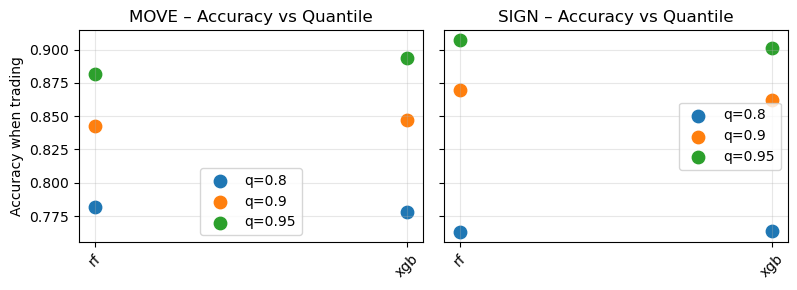

In [19]:
quantiles = [0.8, 0.9, 0.95]

model_names = list(move_results.keys())
x = np.arange(len(model_names))

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for q in quantiles:

    accs = []

    for name in model_names:
        preds = np.nansum(move_results[name]["fold_oof"], axis=0)

        threshold = np.quantile(preds, q)
        signal = preds > threshold

        acc = y_move.values[signal].mean()
        accs.append(acc)

    axes[0].scatter(x, accs, label=f"q={q}", s=80)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45)
axes[0].set_title("MOVE – Accuracy vs Quantile")
axes[0].set_ylabel("Accuracy when trading")
axes[0].grid(alpha=0.3)
axes[0].legend()


for q in quantiles:

    accs = []

    for name in model_names:
        preds = np.nansum(sign_results[name]["fold_oof"], axis=0)

        threshold = np.quantile(preds, q)
        signal = preds > threshold

        acc = y_sign.values[signal].mean()
        accs.append(acc)

    axes[1].scatter(x, accs, label=f"q={q}", s=80)

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45)
axes[1].set_title("SIGN – Accuracy vs Quantile")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Signal Construction and Backtesting

Model outputs are converted into trading signals using:

- `move_preds` to filter for high-confidence opportunities  
- `sign_preds` to determine direction  

Signal:

signal = 0 (no trade)  
signal = move_preds * (2 * sign_preds - 1) (when move_preds passes threshold)

Optionally scaled:

signal = move_preds * (2 * sign_preds - 1)

Execution is lagged to avoid lookahead:

PnL_t = signal_{t-1} * return_t (i.e look at signal at t-1 trade at time t, realise gains at time t+1)

We now evaluate whether these signals produce tradable performance.

In [20]:
# Combine predictions

move_preds = pd.Series(np.nanmean(move_results["xgb"]["fold_oof"], axis=0))
sign_preds = pd.Series(np.nanmean(sign_results["xgb"]["fold_oof"], axis=0))
returns = final_dataset["mid_price_change_1"]

valid = sign_preds.notna() & move_preds.notna()

sign_preds = sign_preds[valid]
move_preds = move_preds[valid]
returns = returns[valid]

C:\Users\jayod\AppData\Local\Temp\ipykernel_19000\3936389111.py:3: RuntimeWarning: Mean of empty slice
  move_preds = pd.Series(np.nanmean(move_results["xgb"]["fold_oof"], axis=0))
C:\Users\jayod\AppData\Local\Temp\ipykernel_19000\3936389111.py:4: RuntimeWarning: Mean of empty slice
  sign_preds = pd.Series(np.nanmean(sign_results["xgb"]["fold_oof"], axis=0))


In [21]:
from scipy.stats import spearmanr


def compute_strategy_performance(pnl: pd.Series):
    mean_return = pnl.mean()
    volatility = pnl.std()
    total_pnl = pnl.sum()

    sharpe = mean_return / volatility if volatility != 0 else np.nan

    cum_pnl = pnl.cumsum()

    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max
    max_drawdown = drawdown.min()

    hit_rate = (pnl > 0).mean()

    skew = pnl.skew()
    kurtosis = pnl.kurtosis()

    return {
        "sharpe": sharpe,
        "total_pnl": total_pnl,
        "mean_return": mean_return,
        "volatility": volatility,
        "max_drawdown": max_drawdown,
        "hit_rate": hit_rate,
    }


def compute_trading_behaviour(signal: pd.Series, pnl: pd.Series):
    trade_mask = signal != 0

    trade_freq = trade_mask.mean()

    pnl_trade = pnl[trade_mask]

    avg_trade_pnl = pnl_trade.mean()

    trade_vol = pnl_trade.std()
    trade_sharpe = avg_trade_pnl / trade_vol if trade_vol != 0 else np.nan

    abs_signal = signal.abs()
    avg_position = abs_signal.mean()
    max_position = abs_signal.max()

    return {
        "trade_freq": trade_freq,
        "avg_trade_pnl": avg_trade_pnl,
        "trade_sharpe": trade_sharpe,
        "avg_position": avg_position,
        "max_position": max_position,
    }


def compute_combined_model_diagnostics(
    signal: pd.Series,
    returns: pd.Series,
    pnl: pd.Series,
):

    trade_mask = signal != 0
    non_zero_mask = returns != 0

    pnl_nz = pnl[non_zero_mask]
    avg_pnl_nz = pnl_nz.mean()

    pred_direction = np.sign(signal)
    true_direction = np.sign(returns)

    valid_dir = non_zero_mask & (signal != 0)

    accuracy_nz = (pred_direction[valid_dir] == true_direction[valid_dir]).mean()

    move_coverage = (trade_mask & non_zero_mask).sum() / max(non_zero_mask.sum(), 1)

    wasted_trades = (trade_mask & ~non_zero_mask).mean()

    missed_moves = (~trade_mask & non_zero_mask).mean()

    return {
        "avg_pnl_when_move": avg_pnl_nz,
        "directional_accuracy_when_move": accuracy_nz,
        "move_coverage": move_coverage,
        "wasted_trades": wasted_trades,
        "missed_moves": missed_moves,
    }


def signal_quality_metrics(signal, returns, n_quantiles=10):

    df = pd.concat([signal, returns], axis=1).dropna()
    s = df.iloc[:, 0]
    r = df.iloc[:, 1]

    ic = spearmanr(s, r).correlation

    nz_mask = r != 0

    ic_nz = spearmanr(s[nz_mask], r[nz_mask]).correlation

    # --- Quantile performance ---
    try:
        q = pd.qcut(s, n_quantiles, duplicates="drop")
        quantile_means = r.groupby(q).mean()
        top_vs_rest = quantile_means.iloc[-1] - quantile_means.iloc[:-1].mean()
    except:
        quantile_means = None
        top_vs_rest = np.nan

    return {
        "ic": ic,
        "ic_non_zero": ic_nz,
        "quantile_means": quantile_means,
        "top_vs_rest": top_vs_rest,
    }

In [ ]:
def evaluate_strategy(
    sign_preds: pd.Series,
    move_preds: pd.Series,
    returns: pd.Series,
    move_quantile: float = 0.9,
    sign_threshold: float = 0.6,
    annualisation_factor: float = 1.0,
):
    assert sign_preds.index.equals(move_preds.index)
    assert sign_preds.index.equals(returns.index)

    signal = move_preds * (2 * sign_preds - 1)

    move_threshold = np.quantile(move_preds, move_quantile)
    move_filter = move_preds > move_threshold

    strong_up = sign_preds > sign_threshold
    strong_down = sign_preds < (1 - sign_threshold)
    sign_filter = strong_up | strong_down

    # Filter
    signal[~move_filter] = 0.0
    signal[~sign_filter] = 0.0

    # Shift

    signal = signal.shift(1)

    valid = signal.notna()
    signal = signal[valid]
    returns = returns[valid]
    assert signal.index.equals(returns.index)

    # PNL

    pnl = signal * returns

    # Metrics
    strategy_metric = compute_strategy_performance(pnl)
    trading_behaviour = compute_trading_behaviour(signal, pnl)
    model_diagnostics = compute_combined_model_diagnostics(signal, returns, pnl)
    signal_quality = signal_quality_metrics(signal, returns, n_quantiles=10)

    all_metrics = {
        **strategy_metric,
        **trading_behaviour,
        **model_diagnostics,
        **signal_quality,
    }

    return all_metrics, pnl, signal

In [37]:
all_metrics, pnl, signal = evaluate_strategy(
    sign_preds=sign_preds,
    move_preds=move_preds,
    returns=returns,
    move_quantile=0.9,
    sign_threshold=0.9,
)

In [38]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Metric", "Value"]

for k, v in all_metrics.items():

    if k == "quantile_means":
        continue

    table.add_row([k, round(v, 4)])

print(table)

+--------------------------------+-----------+
|             Metric             |   Value   |
+--------------------------------+-----------+
|             sharpe             |   0.019   |
|           total_pnl            |  537.4897 |
|          mean_return           |   0.0302  |
|           volatility           |   1.5915  |
|          max_drawdown          | -140.9424 |
|            hit_rate            |   0.0216  |
|           trade_freq           |   0.0364  |
|         avg_trade_pnl          |   0.8295  |
|          trade_sharpe          |   0.0999  |
|          avg_position          |   0.0311  |
|          max_position          |   0.973   |
|       avg_pnl_when_move        |   0.0302  |
| directional_accuracy_when_move |   0.5926  |
|         move_coverage          |   0.0364  |
|         wasted_trades          |    0.0    |
|          missed_moves          |   0.9636  |
|               ic               |   0.0212  |
|          ic_non_zero           |   0.0212  |
|          to

In [43]:
import numpy as np
import pandas as pd

move_quantiles = np.linspace(0.1, 0.99, 40)
sign_thresholds = np.linspace(0.5, 0.99, 40)

results = []

for mq in move_quantiles:
    for st in sign_thresholds:

        all_metrics, pnl, signal = evaluate_strategy(
            sign_preds=sign_preds,
            move_preds=move_preds,
            returns=returns,
            move_quantile=mq,
            sign_threshold=st,
        )

        trade_freq = all_metrics["trade_freq"]
        trade_sharpe = all_metrics["trade_sharpe"]

        # --- constraint ---
        if trade_freq < 0.05:
            continue

        # --- objective ---
        score = trade_sharpe * np.sqrt(trade_freq)

        results.append({
            "move_q": mq,
            "sign_th": st,
            "score": score,
            **all_metrics
        })

# convert to df
df = pd.DataFrame(results)

# best config
best = df.sort_values("score", ascending=False).iloc[0]

print(best)

move_q                                                                          0.1
sign_th                                                                    0.600513
score                                                                      0.080935
sharpe                                                                     0.080845
total_pnl                                                               7102.150848
mean_return                                                                0.399446
volatility                                                                 4.940903
max_drawdown                                                            -237.651959
hit_rate                                                                   0.431046
trade_freq                                                                 0.744207
avg_trade_pnl                                                              0.536741
trade_sharpe                                                               0

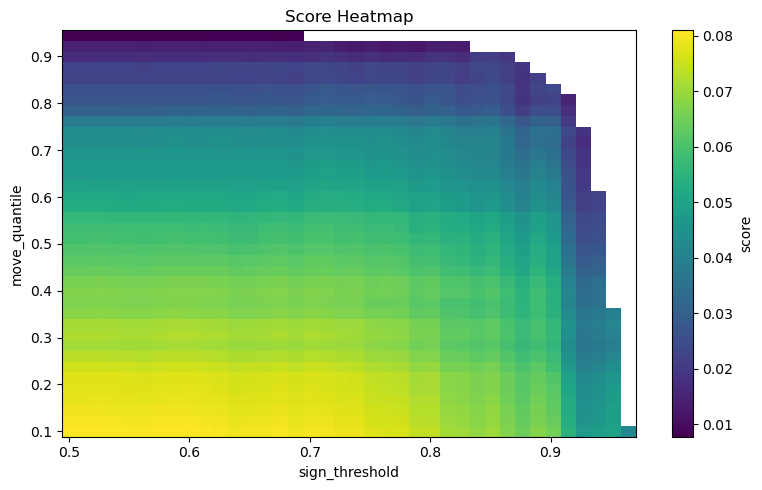

In [49]:
import matplotlib.pyplot as plt

pivot = df.pivot(index="move_q", columns="sign_th", values="score")
pivot = pivot.sort_index().sort_index(axis=1)

plt.figure(figsize=(8, 5))

plt.pcolormesh(
    pivot.columns,
    pivot.index,
    pivot.values,
    shading="auto"
)

plt.colorbar(label="score")

plt.xlabel("sign_threshold")
plt.ylabel("move_quantile")
plt.title("Score Heatmap")

plt.tight_layout()
plt.show()